<a href="https://colab.research.google.com/github/rohit18-03/Driver-Drowsiness-Detection/blob/main/Copy_of_subject_wise_split.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

data_path = "E:\DDD_Project\DROZY"

for root, dirs, files in os.walk(data_path):
    print(f"\n📁 Directory: {root}")
    print("Subfolders:", dirs)
    print("Files:", files)



📁 Directory: E:\DDD_Project\DROZY
Subfolders: ['annotations-manual', 'interpIndices', 'psg', 'pvt-rt', 'timestamps', 'videos_i8']
Files: ['KSS.txt']

📁 Directory: E:\DDD_Project\DROZY\annotations-manual
Subfolders: ['1', '2', '3']
Files: []

📁 Directory: E:\DDD_Project\DROZY\annotations-manual\1
Subfolders: ['depth', 'nir']
Files: ['annot-s2.txt', 'annot-s3.txt', 'annot-timestamps.txt']

📁 Directory: E:\DDD_Project\DROZY\annotations-manual\1\depth
Subfolders: []
Files: ['0.png', '1.png', '10.png', '11.png', '12.png', '13.png', '14.png', '15.png', '16.png', '17.png', '18.png', '19.png', '2.png', '20.png', '21.png', '22.png', '23.png', '24.png', '25.png', '26.png', '27.png', '28.png', '29.png', '3.png', '30.png', '31.png', '32.png', '33.png', '34.png', '35.png', '36.png', '37.png', '38.png', '39.png', '4.png', '40.png', '41.png', '42.png', '43.png', '44.png', '45.png', '46.png', '47.png', '48.png', '49.png', '5.png', '50.png', '6.png', '7.png', '8.png', '9.png']

📁 Directory: E:\DDD_Pro

<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:3: SyntaxWarning: invalid escape sequence '\D'
C:\Users\mohit\AppData\Local\Temp\ipykernel_18024\3334065269.py:3: SyntaxWarning: invalid escape sequence '\D'
  data_path = "E:\DDD_Project\DROZY"


In [ ]:
edf_files = []

for root, dirs, files in os.walk(data_path):
    for file in files:
        if file.endswith(".edf"):
            edf_files.append(os.path.join(root, file))

print("Total EDF files:", len(edf_files))
print("First 5 EDF files:")
for f in edf_files[:5]:
    print(f)


Total EDF files: 36
First 5 EDF files:
E:\DDD_Project\DROZY\psg\1-1.edf
E:\DDD_Project\DROZY\psg\1-2.edf
E:\DDD_Project\DROZY\psg\1-3.edf
E:\DDD_Project\DROZY\psg\10-1.edf
E:\DDD_Project\DROZY\psg\10-3.edf


In [ ]:
!pip install pyedflib


In [ ]:
import pyedflib
import numpy as np

sample_file = edf_files[0]
print("Opening:", sample_file)

f = pyedflib.EdfReader(sample_file)

print("\nNumber of signals:", f.signals_in_file)
print("Signal labels:", f.getSignalLabels())
print("Sampling frequencies:", f.getSampleFrequencies())

# Read first channel (we will adjust after seeing labels)
signal = f.readSignal(0)

print("\nSignal shape:", signal.shape)
print("Signal duration (sec):", len(signal)/f.getSampleFrequency(0))

f.close()


Opening: E:\DDD_Project\DROZY\psg\1-1.edf

Number of signals: 12
Signal labels: ['Fz', 'Cz', 'C3', 'C4', 'Pz', 'Oz', 'Cam-Sync', 'PVT', 'EOG-V', 'EOG-H', 'EMG', 'ECG']
Sampling frequencies: [512. 512. 512. 512. 512. 512. 512. 512. 512. 512. 512. 512.]

Signal shape: (307200,)
Signal duration (sec): 600.0


In [ ]:
kss_file = os.path.join(data_path, "KSS.txt")

with open(kss_file, "r") as f:
    lines = f.readlines()

print("Total KSS entries:", len(lines))
print("First 5 entries:")
print(lines[:5])


Total KSS entries: 14
First 5 entries:
['3 6 7\n', '3 7 6\n', '2 3 4\n', '4 8 9\n', '3 7 8\n']


In [ ]:
import os
import pyedflib
import numpy as np
import pandas as pd

data_path = r"E:\DDD_Project\DROZY"

# -------------------------
# 1️⃣ Load KSS file
# -------------------------
kss_path = os.path.join(data_path, "KSS.txt")

kss_dict = {}

with open(kss_path, "r") as f:
    lines = f.readlines()

for subj_id, line in enumerate(lines, start=1):
    scores = list(map(int, line.strip().split()))
    kss_dict[subj_id] = scores  # 3 session scores

print("Loaded KSS for", len(kss_dict), "subjects")


# -------------------------
# 2️⃣ KSS → 2 Classes
def kss_to_label(score):
    if score <= 3:
        return 0   # Alert
    else:
        return 1   # Drowsy (Moderate + Fatigued)


# -------------------------
# 3️⃣ Load ECG + Labels
# -------------------------
rows = []


import glob
import os

# Find ALL edf files recursively
edf_files = glob.glob(os.path.join(data_path, "**", "*.edf"), recursive=True)

print("Total EDF files found:", len(edf_files))

rows = []

for file_path in edf_files:

    file = os.path.basename(file_path)

    # Extract subject-session from filename (e.g., 1-2.edf)
    subj, session = file.replace(".edf", "").split("-")
    subj = int(subj)
    session = int(session) - 1  # convert to 0-based index

    # Get KSS score
    kss_score = kss_dict[subj][session]
    label = kss_to_label(kss_score)

    # Read EDF
    edf = pyedflib.EdfReader(file_path)
    signal_labels = edf.getSignalLabels()

    # Find ECG channel safely
    ecg_index = None
    for i, ch in enumerate(signal_labels):
        if "ECG" in ch.upper():
            ecg_index = i
            break

    if ecg_index is None:
        edf.close()
        continue

    ecg_signal = edf.readSignal(ecg_index)
    edf.close()

    row = [subj, file, label] + ecg_signal.tolist()
    rows.append(row)

print("Total files processed:", len(rows))

# -------------------------
# 4️⃣ Convert to DataFrame
# -------------------------

# Determine ECG length dynamically
ecg_length = len(rows[0]) - 3

columns = ["Subject", "File", "Label"] + [f"ECG_{i}" for i in range(ecg_length)]

df = pd.DataFrame(rows, columns=columns)

print("Final Data Shape:", df.shape)


# -------------------------
# 5️⃣ Save CSV (Kaggle Output Folder)
# -------------------------

output_path = r"E:\DDD_Project\output\drozy_ecg_dataset.csv"
df.to_csv(output_path, index=False)

print("CSV saved successfully at:", output_path)


Loaded KSS for 14 subjects
Total EDF files found: 36
Total files processed: 36
Final Data Shape: (36, 307203)
CSV saved successfully at: E:\DDD_Project\output\drozy_ecg_dataset.csv


In [ ]:
import pandas as pd

# Load the dataset
file_path = r"E:\DDD_Project\output\drozy_ecg_dataset.csv"
df = pd.read_csv(file_path)

# Print first 5 rows
print(df.head())


   Subject      File  Label       ECG_0       ECG_1       ECG_2       ECG_3  \
0        1   1-1.edf      0   11.230811   11.719108   12.988678    5.761895   
1        1   1-2.edf      1  145.219275  150.395215  149.125645  139.262062   
2        1   1-3.edf      1   86.037782   85.647145   72.072512   54.786828   
3       10  10-1.edf      0  129.300821  190.826136  263.093966  325.498215   
4       10  10-3.edf      1   27.051607   32.032228   39.259011   45.509201   

        ECG_4       ECG_5       ECG_6  ...  ECG_307190  ECG_307191  \
0   -7.129124  -16.406751  -15.820795  ...   84.670553   82.522050   
1  128.226569  124.027223  125.101474  ...  102.053896  100.686666   
2   42.970061   39.747307   45.313883  ... -543.375958 -553.141881   
3  363.682974  387.023530  407.531968  ...  -29.395428  -30.957976   
4   46.388134   42.579424   42.384106  ...  -12.500381  -17.773980   

   ECG_307192  ECG_307193  ECG_307194  ECG_307195  ECG_307196  ECG_307197  \
0   78.908658   75.392926  

In [ ]:
print("Shape:", df.shape)



Shape: (36, 307203)


In [ ]:
import pandas as pd

file_path = r"E:\DDD_Project\output\drozy_ecg_dataset.csv"

# Columns we care about
cols = ['Label', 'Subject', 'File']

# Sets to store unique values
unique_label = set()
unique_subject = set()
unique_file = set()

# Read in chunks
for chunk in pd.read_csv(file_path, usecols=cols, chunksize=100000):
    unique_label.update(chunk['Label'].unique())
    unique_subject.update(chunk['Subject'].unique())
    unique_file.update(chunk['File'].unique())

# Print results
print("Unique Label count:", len(unique_label))
print("Unique Subject count:", len(unique_subject))
print("Unique File count:", len(unique_file))


Unique Label count: 2
Unique Subject count: 14
Unique File count: 36


In [ ]:
print("Labels:", unique_label)
print("Subjects:", unique_subject)
print("Files (sorted by File column):", sorted(unique_file), "...")




Labels: {np.int64(0), np.int64(1)}
Subjects: {np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)}
Files (sorted by File column): ['1-1.edf', '1-2.edf', '1-3.edf', '10-1.edf', '10-3.edf', '11-1.edf', '11-2.edf', '11-3.edf', '12-1.edf', '13-1.edf', '13-2.edf', '14-1.edf', '14-2.edf', '14-3.edf', '2-1.edf', '2-2.edf', '2-3.edf', '3-1.edf', '3-2.edf', '3-3.edf', '4-1.edf', '4-2.edf', '4-3.edf', '5-1.edf', '5-2.edf', '5-3.edf', '6-1.edf', '6-2.edf', '6-3.edf', '7-2.edf', '7-3.edf', '8-1.edf', '8-2.edf', '8-3.edf', '9-2.edf', '9-3.edf'] ...


In [ ]:
import re

def file_sort_key(filename):
    # Extract numbers before and after "-"
    match = re.match(r"(\d+)-(\d+)\.edf", filename)
    if match:
        return (int(match.group(1)), int(match.group(2)))
    return (float('inf'), float('inf'))

sorted_files = sorted(unique_file, key=file_sort_key)

print("Files (properly sorted):", sorted_files)


Files (properly sorted): ['1-1.edf', '1-2.edf', '1-3.edf', '2-1.edf', '2-2.edf', '2-3.edf', '3-1.edf', '3-2.edf', '3-3.edf', '4-1.edf', '4-2.edf', '4-3.edf', '5-1.edf', '5-2.edf', '5-3.edf', '6-1.edf', '6-2.edf', '6-3.edf', '7-2.edf', '7-3.edf', '8-1.edf', '8-2.edf', '8-3.edf', '9-2.edf', '9-3.edf', '10-1.edf', '10-3.edf', '11-1.edf', '11-2.edf', '11-3.edf', '12-1.edf', '13-1.edf', '13-2.edf', '14-1.edf', '14-2.edf', '14-3.edf']


In [ ]:
import numpy as np
import pandas as pd
import os

input_path = r"E:\DDD_Project\output\drozy_ecg_dataset.csv"
save_path = r"E:\DDD_Project\output\drozy_ecg_segmented_20s.npz"

fs = 512
window_sec = 20
overlap_sec = 10

window_size = fs * window_sec      # 10240
step_size = fs * (window_sec - overlap_sec)  # 5120

df = pd.read_csv(input_path)

ecg_cols = [col for col in df.columns if col.startswith("ECG_")]

X_segments = []
y_segments = []
subjects = []

for idx, row in df.iterrows():

    subject = row["Subject"]
    label = row["Label"]

    ecg_signal = row[ecg_cols].values.astype(np.float32)

    for start in range(0, len(ecg_signal) - window_size + 1, step_size):
        end = start + window_size
        segment = ecg_signal[start:end]

        X_segments.append(segment)
        y_segments.append(label)
        subjects.append(subject)

X_segments = np.array(X_segments)
y_segments = np.array(y_segments)
subjects = np.array(subjects)

print("Segments shape:", X_segments.shape)
print("Labels shape:", y_segments.shape)

np.savez(save_path, X=X_segments, y=y_segments, subjects=subjects)

print("Saved as:", save_path)

Segments shape: (2124, 10240)
Labels shape: (2124,)
Saved as: E:\DDD_Project\output\drozy_ecg_segmented_20s.npz


In [ ]:
import numpy as np

file_path = r"E:\DDD_Project\output\drozy_ecg_segmented_20s.npz"

data = np.load(file_path)

X = data["X"]
y = data["y"]
subjects = data["subjects"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("subjects shape:", subjects.shape)


X shape: (2124, 10240)
y shape: (2124,)
subjects shape: (2124,)


In [ ]:
# ==================================
# BALANCED SUBJECT SPLIT
# ==================================

import numpy as np

# Compute subject-level dominant class
subject_labels = {}

for subj in np.unique(subjects):
    subj_indices = np.where(subjects == subj)[0]
    subj_labels = y[subj_indices]
    dominant = np.argmax(np.bincount(subj_labels.astype(int)))
    subject_labels[subj] = dominant

# Separate subjects by dominant label
alert_subjects = [s for s in subject_labels if subject_labels[s] == 0]
drowsy_subjects = [s for s in subject_labels if subject_labels[s] == 1]

np.random.seed(42)
np.random.shuffle(alert_subjects)
np.random.shuffle(drowsy_subjects)

# Split 70-15-15 roughly within each group
def split_group(group):
    n = len(group)
    n_test = int(0.2 * n)
    n_val = int(0.15 * (n - n_test))
    test = group[:n_test]
    val = group[n_test:n_test+n_val]
    train = group[n_test+n_val:]
    return train, val, test

train_a, val_a, test_a = split_group(alert_subjects)
train_d, val_d, test_d = split_group(drowsy_subjects)

train_subjects = train_a + train_d
val_subjects = val_a + val_d
test_subjects = test_a + test_d

print("Train subjects:", train_subjects)
print("Val subjects:", val_subjects)
print("Test subjects:", test_subjects)

Train subjects: [np.int64(13), np.int64(10), np.int64(3), np.int64(12), np.int64(5), np.int64(9), np.int64(4), np.int64(2), np.int64(14), np.int64(7), np.int64(11)]
Val subjects: [np.int64(1)]
Test subjects: [np.int64(6), np.int64(8)]


In [ ]:
import numpy as np

train_path = r"E:\DDD_Project\output\drozy_train.npz"
val_path   = r"E:\DDD_Project\output\drozy_val.npz"
test_path  = r"E:\DDD_Project\output\drozy_test.npz"

def print_unique_subjects(file_path, name):

    data = np.load(file_path)

    # subjects were not saved in split files yet?
    # If you saved subjects earlier, load like this:
    if "subjects" in data:
        subjects = data["subjects"]
        unique_subjects = np.unique(subjects)
    else:
        print(f"{name}: No subject information stored.")
        return

    print(f"\n{name} - Unique Subjects ({len(unique_subjects)}):")
    print(sorted(unique_subjects))


print_unique_subjects(train_path, "TRAIN")
print_unique_subjects(val_path, "VALIDATION")
print_unique_subjects(test_path, "TEST")


TRAIN - Unique Subjects (11):
[np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(11), np.int64(13), np.int64(14)]

VALIDATION - Unique Subjects (1):
[np.int64(1)]

TEST - Unique Subjects (2):
[np.int64(10), np.int64(12)]


In [ ]:
import numpy as np

train_path = r"E:\DDD_Project\output\drozy_train.npz"
val_path   = r"E:\DDD_Project\output\drozy_val.npz"
test_path  = r"E:\DDD_Project\output\drozy_test.npz"

def inspect_npz(path, name):
    data = np.load(path)
    X = data["X"]
    y = data["y"]

    print(f"\n===== {name} =====")
    print("X shape:", X.shape)
    print("y shape:", y.shape)
    print("First 5 labels:", y[:5])
    print("First segment (first 10 values):", X[0][:10])

inspect_npz(train_path, "TRAIN")
inspect_npz(val_path, "VALIDATION")
inspect_npz(test_path, "TEST")



===== TRAIN =====
X shape: (1770, 10240)
y shape: (1770,)
First 5 labels: [1 1 1 1 1]
First segment (first 10 values): [ 2.3438215   1.6602069   1.4648885   1.4648885   0.5859554  -0.8789331
 -1.1719108   0.78127384  2.929777    2.6367993 ]

===== VALIDATION =====
X shape: (177, 10240)
y shape: (177,)
First 5 labels: [0 0 0 0 0]
First segment (first 10 values): [ 11.230811   11.719108   12.988678    5.7618947  -7.1291237 -16.406752
 -15.820795   -4.589984   13.574633   28.711813 ]

===== TEST =====
X shape: (177, 10240)
y shape: (177,)
First 5 labels: [0 0 0 0 0]
First segment (first 10 values): [129.30083 190.82614 263.09396 325.4982  363.68298 387.02353 407.53198
 416.51663 400.59818 368.27295]


In [ ]:
import numpy as np

train_path = r"E:\DDD_Project\output\drozy_train.npz"
val_path   = r"E:\DDD_Project\output\drozy_val.npz"
test_path  = r"E:\DDD_Project\output\drozy_test.npz"

# Load datasets
train_data = np.load(train_path)
val_data   = np.load(val_path)
test_data  = np.load(test_path)

X_sig_train_full = train_data["X"]
y_train_full     = train_data["y"]

X_sig_val = val_data["X"]
y_val     = val_data["y"]

X_sig_test = test_data["X"]
y_test     = test_data["y"]

# Add channel dimension for Transformer
X_sig_train_full = X_sig_train_full[..., np.newaxis]
X_sig_val = X_sig_val[..., np.newaxis]
X_sig_test = X_sig_test[..., np.newaxis]

print("Train:", X_sig_train_full.shape, y_train_full.shape)
print("Val:", X_sig_val.shape, y_val.shape)
print("Test:", X_sig_test.shape, y_test.shape)


Train: (1770, 10240, 1) (1770,)
Val: (177, 10240, 1) (177,)
Test: (177, 10240, 1) (177,)


In [ ]:
y_train_full = y_train_full.astype(np.float32)
y_val = y_val.astype(np.float32)
y_test = y_test.astype(np.float32)

In [ ]:
# ===============================
# ECG PER-SEGMENT NORMALIZATION
# ===============================

import numpy as np

def normalize_per_segment(X):
    mean = np.mean(X, axis=1, keepdims=True)
    std = np.std(X, axis=1, keepdims=True) + 1e-8
    return (X - mean) / std

X_sig_train_full = normalize_per_segment(X_sig_train_full)
X_sig_val = normalize_per_segment(X_sig_val)
X_sig_test = normalize_per_segment(X_sig_test)

print("Normalization done.")

Normalization done.


In [ ]:
from scipy.signal import find_peaks

def detect_r_peaks(ecg, fs=512):

    # normalize
    ecg = (ecg - np.mean(ecg)) / np.std(ecg)

    # minimum distance between peaks
    min_distance = int(0.4 * fs)   # 0.4 sec → 150 bpm max

    peaks, _ = find_peaks(
        ecg,
        distance=min_distance,
        height=0.5
    )

    return peaks


In [ ]:
def compute_rr_intervals(peaks, fs=512):

    # convert to seconds
    rr = np.diff(peaks) / fs

    return rr


In [ ]:
from scipy.signal import welch
from scipy.stats import entropy
import numpy as np


# -----------------------------
# Sample Entropy
# -----------------------------
def sample_entropy(signal, m=2, r=0.2):
    signal = np.array(signal)
    N = len(signal)

    if N < m + 2:
        return 0.0

    r *= np.std(signal)

    if r == 0:
        return 0.0

    def _phi(m):
        x = np.array([signal[i:i+m] for i in range(N-m+1)])
        C = 0
        for i in range(len(x)):
            dist = np.max(np.abs(x - x[i]), axis=1)
            C += np.sum(dist <= r) - 1
        return C

    phi_m = _phi(m)
    phi_m1 = _phi(m+1)

    if phi_m == 0 or phi_m1 == 0:
        return 0.0

    return -np.log(phi_m1 / phi_m)



# -----------------------------
# Feature Extraction
# -----------------------------
def extract_features(rr):

    features = []

    # ---------- TIME DOMAIN ----------
    mean_rr = np.mean(rr)
    std_rr = np.std(rr)
    rmssd = np.sqrt(np.mean(np.diff(rr)**2))

    nn50 = np.sum(np.abs(np.diff(rr)) > 0.05)
    pnn50 = nn50 / len(rr)

    hr = 60 / rr
    mean_hr = np.mean(hr)
    std_hr = np.std(hr)

    features.extend([
        mean_rr, std_rr, rmssd,
        nn50, pnn50,
        mean_hr, std_hr
    ])

    # ---------- FREQUENCY DOMAIN (FIXED) ----------

    # Interpolate RR at 4 Hz properly
    fs_rr = 4

    # cumulative time of beats
    time_rr = np.cumsum(rr)
    time_rr = np.insert(time_rr, 0, 0)

    # interpolate over full duration
    interp_time = np.arange(0, time_rr[-1], 1/fs_rr)
    rr_interp = np.interp(interp_time, time_rr[:-1], rr)

    # Welch PSD
    f, psd = welch(rr_interp, fs=fs_rr, nperseg=min(256, len(rr_interp)))

    lf_band = (0.04, 0.15)
    hf_band = (0.15, 0.4)

    lf = np.trapezoid(psd[(f >= lf_band[0]) & (f < lf_band[1])])
    hf = np.trapezoid(psd[(f >= hf_band[0]) & (f < hf_band[1])])

    total_power = lf + hf

    lf_hf_ratio = lf / (hf + 1e-6)
    lf_norm = lf / (total_power + 1e-6)
    hf_norm = hf / (total_power + 1e-6)


    # ---------- NONLINEAR ----------
    shannon_ent = entropy(np.histogram(rr, bins=10)[0] + 1e-6)
    samp_ent = sample_entropy(rr)

    # Poincare
    diff_rr = np.diff(rr)
    sd1 = np.sqrt(np.var(diff_rr) / 2)
    sd2 = np.sqrt(2*np.var(rr) - np.var(diff_rr)/2)

    features.extend([
        shannon_ent,
        samp_ent,
        sd1,
        sd2
    ])

    return np.array(features)


In [ ]:
# from scipy.signal import welch
# from scipy.stats import entropy
# import numpy as np


# # -----------------------------
# # Sample Entropy (Safe Version)
# # -----------------------------
# def sample_entropy(signal, m=2, r=0.2):
#     N = len(signal)
#     if N < m + 2:
#         return 0.0

#     r *= np.std(signal)

#     def _phi(m):
#         x = np.array([signal[i:i+m] for i in range(N-m+1)])
#         C = 0
#         for i in range(len(x)):
#             C += np.sum(np.max(np.abs(x - x[i]), axis=1) <= r) - 1
#         return C

#     phi_m = _phi(m)
#     phi_m1 = _phi(m+1)

#     if phi_m == 0 or phi_m1 == 0:
#         return 0.0

#     return -np.log(phi_m1 / phi_m + 1e-10)


# # -----------------------------
# # Feature Extraction (FIXED)
# # -----------------------------
# def extract_features(rr):

#     features = []

#     # ---------- TIME DOMAIN ----------
#     mean_rr = np.mean(rr)
#     std_rr = np.std(rr)
#     rmssd = np.sqrt(np.mean(np.diff(rr)**2))

#     nn50 = np.sum(np.abs(np.diff(rr)) > 0.05)
#     pnn50 = nn50 / len(rr)

#     hr = 60 / (rr + 1e-6)
#     mean_hr = np.mean(hr)
#     std_hr = np.std(hr)

#     features.extend([
#         mean_rr, std_rr, rmssd,
#         nn50, pnn50,
#         mean_hr, std_hr
#     ])

#     # ---------- FREQUENCY DOMAIN ----------
#     fs_rr = 4

#     time_rr = np.cumsum(rr)
#     time_rr = np.insert(time_rr, 0, 0)

#     interp_time = np.arange(0, time_rr[-1], 1/fs_rr)

#     if len(interp_time) < 4:
#         lf = hf = lf_hf_ratio = lf_norm = hf_norm = 0.0
#     else:
#         rr_interp = np.interp(interp_time, time_rr[:-1], rr)
#         f, psd = welch(rr_interp, fs=fs_rr, nperseg=min(256, len(rr_interp)))

#         lf_band = (0.04, 0.15)
#         hf_band = (0.15, 0.4)

#         lf = np.trapezoid(psd[(f >= lf_band[0]) & (f < lf_band[1])])
#         hf = np.trapezoid(psd[(f >= hf_band[0]) & (f < hf_band[1])])


#         total_power = lf + hf + 1e-6

#         lf_hf_ratio = lf / (hf + 1e-6)
#         lf_norm = lf / total_power
#         hf_norm = hf / total_power

#     features.extend([
#         lf, hf, lf_hf_ratio, lf_norm, hf_norm
#     ])

#     # ---------- NONLINEAR ----------
#     shannon_ent = entropy(np.histogram(rr, bins=10)[0] + 1e-6)
#     samp_ent = sample_entropy(rr)

#     diff_rr = np.diff(rr)
#     sd1 = np.sqrt(np.var(diff_rr) / 2)
#     sd2 = np.sqrt(2*np.var(rr) - np.var(diff_rr)/2)

#     features.extend([
#         shannon_ent,
#         samp_ent,
#         sd1,
#         sd2
#     ])

#     return np.array(features, dtype=np.float32)


In [ ]:
# from scipy.signal import welch
# from scipy.stats import entropy, skew, kurtosis
# import numpy as np


# def extract_features(rr):

#     features = []

#     # ==========================================================
#     # ---------------- HANDCRAFTED (TRADITIONAL) ----------------
#     # ==========================================================

#     # ---------------- TIME DOMAIN ----------------
#     mean_rr = np.mean(rr)
#     std_rr = np.std(rr)
#     skew_rr = skew(rr)
#     kurt_rr = kurtosis(rr)

#     rmssd = np.sqrt(np.mean(np.diff(rr)**2))

#     hr = 60 / (rr + 1e-8)

#     mean_hr = np.mean(hr)
#     std_hr = np.std(hr)
#     skew_hr = skew(hr)
#     kurt_hr = kurtosis(hr)

#     percent_hr_above = np.mean(hr > mean_hr + std_hr)
#     percent_hr_below = np.mean(hr < mean_hr - std_hr)

#     percent_rr_above = np.mean(rr > mean_rr + std_rr)
#     percent_rr_below = np.mean(rr < mean_rr - std_rr)

#     features.extend([
#         mean_hr, std_hr, skew_hr, kurt_hr,
#         percent_hr_above, percent_hr_below,

#         mean_rr, std_rr, skew_rr, kurt_rr,
#         rmssd,
#         percent_rr_above, percent_rr_below
#     ])

#     # Waveform-related
#     tpr = np.sum(rr)                     # total period
#     mtpr = np.mean(rr)                   # mean total period

#     features.extend([tpr, mtpr])

#     # ==========================================================
#     # ---------------- FREQUENCY DOMAIN ----------------
#     # ==========================================================

#     fs_rr = 4

#     time_rr = np.cumsum(rr)
#     time_rr = np.insert(time_rr, 0, 0)

#     interp_time = np.arange(0, time_rr[-1], 1/fs_rr)
#     rr_interp = np.interp(interp_time, time_rr[:-1], rr)

#     f, psd = welch(rr_interp, fs=fs_rr, nperseg=min(256, len(rr_interp)))

#     # ---- Raw ECG spectral 0–6 Hz (per 0.1 Hz bins) ----
#     freq_bins = np.arange(0, 6, 0.1)
#     spectral_0_6 = []

#     for i in range(len(freq_bins)-1):
#         band_power = np.trapz(
#             psd[(f >= freq_bins[i]) & (f < freq_bins[i+1])]
#         )
#         spectral_0_6.append(band_power)

#     features.extend(spectral_0_6)

#     # ---- HRV Frequency Bands ----
#     lf_band = (0.04, 0.15)
#     mf_band = (0.15, 0.25)
#     hf_band = (0.25, 0.4)

#     lf = np.trapz(psd[(f >= lf_band[0]) & (f < lf_band[1])])
#     mf = np.trapz(psd[(f >= mf_band[0]) & (f < mf_band[1])])
#     hf = np.trapz(psd[(f >= hf_band[0]) & (f < hf_band[1])])

#     tf = lf + mf + hf

#     # Advanced spectral ratios
#     lf_hf = lf / (hf + 1e-8)
#     lf_tf = lf / (tf + 1e-8)
#     hf_tf = hf / (tf + 1e-8)
#     lf_tf_minus_lf = lf / (tf - lf + 1e-8)
#     hf_tf_minus_lf = hf / (tf - lf + 1e-8)

#     features.extend([
#         lf, mf, hf, tf,
#         lf_hf, lf_tf, hf_tf,
#         lf_tf_minus_lf, hf_tf_minus_lf
#     ])

#     # ==========================================================
#     # ---------------- NONLINEAR FEATURES ----------------
#     # ==========================================================

#     # Shannon entropy
#     hist = np.histogram(rr, bins=10)[0] + 1e-8
#     shannon_ent = entropy(hist)

#     # Sample Entropy
#     def sample_entropy(signal, m=2, r=0.2):
#         N = len(signal)
#         r *= np.std(signal) + 1e-8

#         def _phi(m):
#             x = np.array([signal[i:i+m] for i in range(N-m+1)])
#             C = np.sum([
#                 np.sum(np.max(np.abs(x - x[i]), axis=1) <= r) - 1
#                 for i in range(len(x))
#             ])
#             return C

#         return -np.log((_phi(m+1) + 1e-8) / (_phi(m) + 1e-8))

#     samp_ent = sample_entropy(rr)

#     # RCMSE (simplified multiscale entropy scale=2)
#     coarse_rr = rr.reshape(-1, 2).mean(axis=1) if len(rr) % 2 == 0 else rr[:-1].reshape(-1, 2).mean(axis=1)
#     rcmse = sample_entropy(coarse_rr)

#     # Lyapunov exponent (approximate)
#     lyapunov = np.mean(np.log(np.abs(np.diff(rr)) + 1e-8))

#     # Hurst exponent
#     def hurst_exponent(ts):
#         N = len(ts)
#         T = np.arange(1, N+1)
#         Y = np.cumsum(ts - np.mean(ts))
#         R = np.maximum.accumulate(Y) - np.minimum.accumulate(Y)
#         S = np.std(ts)
#         return np.log(np.mean(R/S + 1e-8)) / np.log(N + 1e-8)

#     hurst = hurst_exponent(rr)

#     # DFA (simplified)
#     def dfa(signal):
#         signal = signal - np.mean(signal)
#         y = np.cumsum(signal)
#         n = len(y)
#         scale = int(n / 4)
#         trend = np.polyfit(np.arange(n), y, 1)
#         detrended = y - np.polyval(trend, np.arange(n))
#         return np.sqrt(np.mean(detrended**2))

#     dfa_val = dfa(rr)

#     # Lag
#     lag = np.mean(np.diff(rr))

#     # Mean period
#     mean_period = mean_rr

#     features.extend([
#         shannon_ent,
#         samp_ent,
#         rcmse,
#         lyapunov,
#         hurst,
#         dfa_val,
#         lag,
#         mean_period
#     ])

#     return np.array(features)


In [ ]:
!pip install tqdm

In [ ]:
from tqdm import tqdm

def compute_handcrafted_features(X_sig):

    X_features = []

    for i in tqdm(range(len(X_sig))):

        ecg = X_sig[i].reshape(-1)   # 🔥 FIX HERE

        peaks = detect_r_peaks(ecg)

        if len(peaks) < 5:
            X_features.append(np.zeros(11, dtype=np.float32))
            continue

        rr = compute_rr_intervals(peaks)

        try:
            features = extract_features(rr)

            if len(features) != 11 or np.any(np.isnan(features)):
                features = np.zeros(11, dtype=np.float32)

        except:
            features = np.zeros(11, dtype=np.float32)

        X_features.append(features)

    return np.array(X_features, dtype=np.float32)


In [ ]:

X_features_train = compute_handcrafted_features(X_sig_train_full)
X_features_val   = compute_handcrafted_features(X_sig_val)
X_features_test  = compute_handcrafted_features(X_sig_test)

print("Train features:", X_features_train.shape)
print("Val features:", X_features_val.shape)
print("Test features:", X_features_test.shape)


100%|██████████| 177/177 [00:00<00:00, 563.23it/s]

Train features: (1770, 11)
Val features: (177, 11)
Test features: (177, 11)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_features_scaled_train = scaler.fit_transform(X_features_train)

print("Scaled feature shape:", X_features_scaled_train.shape)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_features_scaled_val = scaler.fit_transform(X_features_val)

print("Scaled feature shape:", X_features_scaled_val.shape)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_features_scaled_test = scaler.fit_transform(X_features_test)

print("Scaled feature shape:", X_features_scaled_test.shape)


Scaled feature shape: (1770, 11)
Scaled feature shape: (177, 11)
Scaled feature shape: (177, 11)


In [ ]:
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
import tensorflow as tf

def build_hybrid_model():

    input_sig = Input(shape=X_sig_train_full.shape[1:])
    input_hand = Input(shape=X_features_scaled_train.shape[1:])

    # ======================================
    # ECG TRANSFORMER (Improved Version)
    # ======================================

    # Better patch embedding (more information preserved)
    # Strong token reduction
    x = Conv1D(32, kernel_size=256, strides=256, padding="valid")(input_sig)
    x = LayerNormalization()(x)

    seq_len = x.shape[1]

    # Positional embedding (must match 32 filters)
    pos_embedding = Embedding(input_dim=seq_len, output_dim=32)(
        tf.range(start=0, limit=seq_len, delta=1)
    )

    x = x + pos_embedding

    # -------- Transformer Block 1 --------
    attn_output = MultiHeadAttention(
        num_heads=2,
        key_dim=16,
        dropout=0.3
    )(x, x)

    attn_output = Dropout(0.3)(attn_output)
    x = Add()([x, attn_output])
    x = LayerNormalization()(x)

    ffn = Dense(
        64,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)
    )(x)

    ffn = Dropout(0.3)(ffn)
    ffn = Dense(32)(ffn)

    x = Add()([x, ffn])
    x = LayerNormalization()(x)

    # -------- Transformer Block 2 --------
    attn_output = MultiHeadAttention(
        num_heads=2,
        key_dim=16,
        dropout=0.3
    )(x, x)

    attn_output = Dropout(0.3)(attn_output)
    x = Add()([x, attn_output])
    x = LayerNormalization()(x)

    ffn = Dense(
        64,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)
    )(x)

    ffn = Dropout(0.3)(ffn)
    ffn = Dense(32)(ffn)

    x = Add()([x, ffn])
    x = LayerNormalization()(x)

    # Global pooling
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.5)(x)

    # ======================================
    # HRV BRANCH (Regularized)
    # ======================================

    y = Dense(
        32,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)
    )(input_hand)

    y = Dropout(0.5)(y)

    # ======================================
    # Fusion
    # ======================================

    combined = Concatenate()([x, y])

    z = Dense(
        32,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)
    )(combined)

    z = Dropout(0.6)(z)

    output = Dense(1, activation="sigmoid")(z)
    model = Model(inputs=[input_sig, input_hand], outputs=output)

    return model

In [ ]:
model_hybrid = build_hybrid_model()

In [ ]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=3e-5
)

model_hybrid.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

checkpoint = ModelCheckpoint(
    "best_hybrid.weights.h5",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True,
    mode="min",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=50,
    restore_best_weights=True,
    verbose=1
)

lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=7,
    min_lr=1e-6,
    verbose=1
)


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_full),
    y=y_train_full
)

class_weights = dict(enumerate(class_weights))

print("Class Weights:", class_weights)

Class Weights: {0: np.float64(1.875), 1: np.float64(0.6818181818181818)}


In [ ]:
# ==================================
# ECG PER-SEGMENT NORMALIZATION
# ==================================

def normalize_per_segment(X):
    X_norm = np.zeros_like(X)
    for i in range(len(X)):
        mean = np.mean(X[i])
        std = np.std(X[i]) + 1e-8
        X_norm[i] = (X[i] - mean) / std
    return X_norm

In [ ]:
# ======================================
# Subject-Level Majority Label Mapping
# ======================================

import numpy as np
from collections import Counter

subjects = df["Subject"].unique()

subject_labels = []

for s in subjects:
    labels = df[df["Subject"] == s]["Label"].values
    majority_label = Counter(labels).most_common(1)[0][0]
    subject_labels.append(majority_label)

subject_labels = np.array(subject_labels)

print("Subjects:", subjects)
print("Subject-level labels:", subject_labels)

Subjects: [ 1 10 11 12 13 14  2  3  4  5  6  7  8  9]
Subject-level labels: [1 0 1 0 1 1 1 0 1 1 0 1 1 1]


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
import tensorflow as tf
import numpy as np
import gc

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_accuracies = []
fold_number = 1

for train_val_idx, test_idx in skf.split(subjects, subject_labels):

    print(f"\n================ FOLD {fold_number} ================")

    train_val_subjects = subjects[train_val_idx]
    test_subjects = subjects[test_idx]

    np.random.shuffle(train_val_subjects)
    n_val = int(0.20 * len(train_val_subjects))

    val_subjects = train_val_subjects[:n_val]
    train_subjects = train_val_subjects[n_val:]

    print("\nTrain Subjects:", sorted(train_subjects))
    print("Validation Subjects:", sorted(val_subjects))
    print("Test Subjects:", sorted(test_subjects))

    # -------------------------------------
    # Create DataFrames
    # -------------------------------------
    train_df = df[df["Subject"].isin(train_subjects)]
    val_df   = df[df["Subject"].isin(val_subjects)]
    test_df  = df[df["Subject"].isin(test_subjects)]

    y_train = train_df["Label"].values.astype(np.int64)
    y_val   = val_df["Label"].values.astype(np.int64)
    y_test  = test_df["Label"].values.astype(np.int64)

    print("\nClass Distribution →")
    print("Train:", Counter(y_train))
    print("Val:", Counter(y_val))
    print("Test:", Counter(y_test))

    # -------------------------------------
    # Extract ECG (RAW, NO NORMALIZATION)
    # -------------------------------------
    X_sig_train = train_df[ecg_cols].values.astype(np.float32)
    X_sig_val   = val_df[ecg_cols].values.astype(np.float32)
    X_sig_test  = test_df[ecg_cols].values.astype(np.float32)

    X_sig_train = X_sig_train[..., np.newaxis]
    X_sig_val   = X_sig_val[..., np.newaxis]
    X_sig_test  = X_sig_test[..., np.newaxis]

    # -------------------------------------
    # Handcrafted Features
    # -------------------------------------
    X_feat_train = compute_handcrafted_features(X_sig_train.squeeze(-1))
    X_feat_val   = compute_handcrafted_features(X_sig_val.squeeze(-1))
    X_feat_test  = compute_handcrafted_features(X_sig_test.squeeze(-1))

    scaler = StandardScaler()
    X_feat_train = scaler.fit_transform(X_feat_train)
    X_feat_val   = scaler.transform(X_feat_val)
    X_feat_test  = scaler.transform(X_feat_test)

    # -------------------------------------
    # Class Weights (Binary)
    # -------------------------------------
    class_weights_array = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(y_train),
        y=y_train
    )

    class_weights = {
        0: class_weights_array[0],
        1: class_weights_array[1]
    }

    print("Class Weights:", class_weights)

    # -------------------------------------
    # Set globals for model
    # -------------------------------------
    X_sig_train_full = X_sig_train
    X_features_scaled_train = X_feat_train

    # -------------------------------------
    # Build Model
    # -------------------------------------
    model = build_hybrid_model()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    '''early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    # -------------------------------------
    # Train
    # -------------------------------------
    model.fit(
        [X_sig_train, X_feat_train],
        y_train,
        validation_data=([X_sig_val, X_feat_val], y_val),
        epochs=50,
        batch_size=16,
        class_weight=class_weights,
        callbacks=[early_stop],
        verbose=1
    )'''
    model.fit(
    [X_sig_train, X_feat_train],
    y_train,
    validation_data=([X_sig_val, X_feat_val], y_val),
    epochs=25,            # fixed epochs
    batch_size=16,
    class_weight=class_weights,
    verbose=1
)

    # -------------------------------------
    # Evaluate
    # -------------------------------------
    loss, acc = model.evaluate(
        [X_sig_test, X_feat_test],
        y_test,
        verbose=0
    )

    print("\nFold Test Accuracy:", acc)
    fold_accuracies.append(acc)

    y_pred_probs = model.predict([X_sig_test, X_feat_test])
    y_pred = (y_pred_probs > 0.5).astype(int).flatten()

    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:\n", cm)

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred, digits=4))

    fold_number += 1

    # -------------------------------------
    # Clear Memory
    # -------------------------------------
    tf.keras.backend.clear_session()
    gc.collect()

c:\Users\mohit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(



================ FOLD 1 ================

Train Subjects: [np.int64(1), np.int64(2), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Validation Subjects: [np.int64(3), np.int64(13)]
Test Subjects: [np.int64(11), np.int64(12), np.int64(14)]

Class Distribution →
Train: Counter({np.int64(1): 17, np.int64(0): 7})
Val: Counter({np.int64(0): 3, np.int64(1): 2})
Test: Counter({np.int64(1): 6, np.int64(0): 1})


100%|██████████| 7/7 [00:00<00:00, 18.70it/s]


Class Weights: {0: np.float64(1.7142857142857142), 1: np.float64(0.7058823529411765)}
Epoch 1/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 819ms/step - accuracy: 0.4583 - loss: 0.8992 - val_accuracy: 0.6000 - val_loss: 0.6672
Epoch 2/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 448ms/step - accuracy: 0.5000 - loss: 0.9819 - val_accuracy: 0.6000 - val_loss: 0.6693
Epoch 3/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 424ms/step - accuracy: 0.5417 - loss: 0.7556 - val_accuracy: 0.6000 - val_loss: 0.6717
Epoch 4/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 455ms/step - accuracy: 0.4583 - loss: 0.8824 - val_accuracy: 0.6000 - val_loss: 0.6753
Epoch 5/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 446ms/step - accuracy: 0.4167 - loss: 1.1199 - val_accuracy: 0.6000 - val_loss: 0.6776
Epoch 6/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 427ms/step - accuracy: 0.4167 - loss: 0.8453 - val_accuracy: 0.6000 - val_loss: 0.6794
Epoch 7/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 415ms/step - accuracy: 0.4167 - loss: 0.7403 - val_accuracy: 0.6000 - val_loss: 0.6815
Epoch 8/25
2/2 ━━━━━━━━━━━━━━━━━

100%|██████████| 8/8 [00:00<00:00, 19.72it/s]


...

Class Weights: {0: np.float64(2.0), 1: np.float64(0.6666666666666666)}
Epoch 1/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 790ms/step - accuracy: 0.7500 - loss: 0.6425 - val_accuracy: 0.6000 - val_loss: 0.6597
Epoch 2/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 434ms/step - accuracy: 0.6667 - loss: 0.8222 - val_accuracy: 0.6000 - val_loss: 0.6577
Epoch 3/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 431ms/step - accuracy: 0.5833 - loss: 0.8772 - val_accuracy: 0.6000 - val_loss: 0.6558
Epoch 4/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 427ms/step - accuracy: 0.4583 - loss: 1.1365 - val_accuracy: 0.6000 - val_loss: 0.6543
Epoch 5/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 430ms/step - accuracy: 0.6250 - loss: 1.0411 - val_accuracy: 0.6000 - val_loss: 0.6524
Epoch 6/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 440ms/step - accuracy: 0.7083 - loss: 0.7070 - val_accuracy: 0.8000 - val_loss: 0.6509
Epoch 7/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 442ms/step - accuracy: 0.5833 - loss: 0.7485 - val_accuracy: 0.8000 - val_loss: 0.6506
Epoch 8/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 451ms/st

100%|██████████| 8/8 [00:00<00:00, 15.82it/s]


Class Weights: {0: np.float64(1.7142857142857142), 1: np.float64(0.7058823529411765)}
Epoch 1/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 908ms/step - accuracy: 0.5833 - loss: 0.8208 - val_accuracy: 0.7500 - val_loss: 0.6884
Epoch 2/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 485ms/step - accuracy: 0.4583 - loss: 0.9639 - val_accuracy: 0.7500 - val_loss: 0.6915
Epoch 3/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 481ms/step - accuracy: 0.4583 - loss: 0.8508 - val_accuracy: 0.7500 - val_loss: 0.6918
Epoch 4/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 481ms/step - accuracy: 0.7083 - loss: 0.6636 - val_accuracy: 0.7500 - val_loss: 0.6929
Epoch 5/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 492ms/step - accuracy: 0.6250 - loss: 0.7319 - val_accuracy: 0.7500 - val_loss: 0.6944
Epoch 6/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 454ms/step - accuracy: 0.5833 - loss: 0.8081 - val_accuracy: 0.7500 - val_loss: 0.6958
Epoch 7/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 441ms/step - accuracy: 0.5000 - loss: 0.9735 - val_accuracy: 0.7500 - val_loss: 0.6969
Epoch 8/25
2/2 ━━━━━━━━━━━━━━━━━

100%|██████████| 6/6 [00:00<00:00, 11.95it/s]


Class Weights: {0: np.float64(1.4444444444444444), 1: np.float64(0.7647058823529411)}
Epoch 1/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 901ms/step - accuracy: 0.4615 - loss: 0.8475 - val_accuracy: 0.5000 - val_loss: 0.7032
Epoch 2/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 521ms/step - accuracy: 0.3846 - loss: 0.7557 - val_accuracy: 0.5000 - val_loss: 0.6937
Epoch 3/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 515ms/step - accuracy: 0.5385 - loss: 0.7463 - val_accuracy: 0.5000 - val_loss: 0.6855
Epoch 4/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step - accuracy: 0.3846 - loss: 0.7301 - val_accuracy: 0.5000 - val_loss: 0.6775
Epoch 5/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step - accuracy: 0.5000 - loss: 0.7982 - val_accuracy: 0.7500 - val_loss: 0.6684
Epoch 6/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step - accuracy: 0.5000 - loss: 0.8028 - val_accuracy: 0.7500 - val_loss: 0.6613
Epoch 7/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 533ms/step - accuracy: 0.4615 - loss: 0.7727 - val_accuracy: 0.7500 - val_loss: 0.6551
Epoch 8/25
2/2 ━━━━━━━━━━━━━━━━━

In [ ]:
print("\n======================================")
print("Cross-Validation Results")
print("======================================")

print("Fold Accuracies:", fold_accuracies)

mean_acc = np.mean(fold_accuracies)
std_acc  = np.std(fold_accuracies)

print(f"\nMean Accuracy: {mean_acc:.4f}")
print(f"Std Deviation: {std_acc:.4f}")
print("======================================")


Cross-Validation Results
Fold Accuracies: [0.2857142984867096, 0.25, 0.2857142984867096, 0.625, 0.6666666865348816]

Mean Accuracy: 0.4226
Std Deviation: 0.1832


In [ ]:
history = model_hybrid.fit(
    [X_sig_train_full, X_features_scaled_train],
    y_train,
    validation_data=([X_sig_val, X_features_scaled_val], y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weights
)

Epoch 1/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 24s 364ms/step - accuracy: 0.5842 - loss: 0.7763 - val_accuracy: 0.6667 - val_loss: 0.6371
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 20s 365ms/step - accuracy: 0.5853 - loss: 0.7593 - val_accuracy: 0.6667 - val_loss: 0.6323
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 21s 383ms/step - accuracy: 0.5927 - loss: 0.7282 - val_accuracy: 0.6667 - val_loss: 0.6252
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 21s 376ms/step - accuracy: 0.6023 - loss: 0.7114 - val_accuracy: 0.6667 - val_loss: 0.6208
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 22s 387ms/step - accuracy: 0.6141 - loss: 0.6909 - val_accuracy: 0.6667 - val_loss: 0.6165
Epoch 6/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 22s 393ms/step - accuracy: 0.5989 - loss: 0.7311 - val_accuracy: 0.6667 - val_loss: 0.6125
Epoch 7/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 21s 374ms/step - accuracy: 0.5881 - loss: 0.6999 - val_accuracy: 0.6667 - val_loss: 0.6071
Epoch 8/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 22s 384ms/step - accuracy: 0.5972 - loss: 0.6898 - val_accu

In [ ]:
loss, acc = model_hybrid.evaluate(
    [X_sig_test, X_features_scaled_test],
    y_test
)

print("Hybrid Accuracy:", acc)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.7797 - loss: 0.5169
Hybrid Accuracy: 0.7796609997749329


In [ ]:
# ==================================
# THRESHOLD TUNING (BINARY)
# ==================================

import numpy as np
from sklearn.metrics import confusion_matrix

# Get predicted probabilities
y_pred_prob = model_hybrid.predict(
    [X_sig_test, X_features_scaled_test]
).flatten()

# Try different thresholds
for threshold in [0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65]:
    y_pred = (y_pred_prob > threshold).astype(int)
    acc = np.mean(y_pred == y_test)
    cm = confusion_matrix(y_test, y_pred)

    print("\n=======================")
    print(f"Threshold: {threshold}")
    print("Accuracy:", acc)
    print("Confusion Matrix:")
    print(cm)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step

Threshold: 0.3
Accuracy: 0.384180790960452
Confusion Matrix:
[[  9 109]
 [  0  59]]

Threshold: 0.4
Accuracy: 0.6271186440677966
Confusion Matrix:
[[52 66]
 [ 0 59]]

Threshold: 0.45
Accuracy: 0.7175141242937854
Confusion Matrix:
[[68 50]
 [ 0 59]]

Threshold: 0.5
Accuracy: 0.7796610169491526
Confusion Matrix:
[[79 39]
 [ 0 59]]

Threshold: 0.55
Accuracy: 0.864406779661017
Confusion Matrix:
[[94 24]
 [ 0 59]]

Threshold: 0.6
Accuracy: 0.8870056497175142
Confusion Matrix:
[[100  18]
 [  2  57]]

Threshold: 0.65
Accuracy: 0.96045197740113
Confusion Matrix:
[[113   5]
 [  2  57]]


In [ ]:
# ==================================
# Verify Subject Leakage
# ==================================

print("Train subjects:", np.unique(train_subjects))
print("Test subjects:", np.unique(test_subjects))

Train subjects: [ 2  3  4  5  7  9 10 11 12 13 14]
Test subjects: [6 8]


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.7797 - loss: 0.5169

Hybrid Test Loss: 0.5169270634651184
Hybrid Test Accuracy: 0.7796609997749329
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step

Confusion Matrix:

[[79 39]
 [ 0 59]]


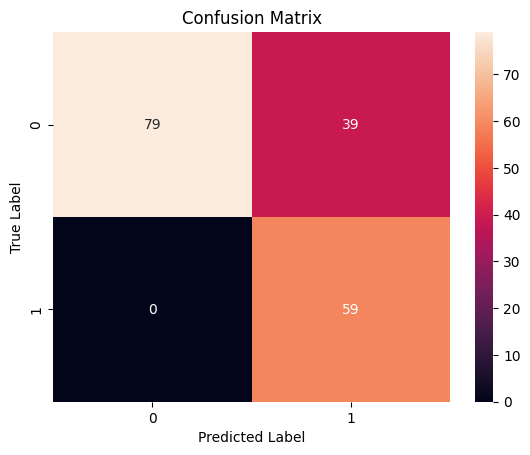


Classification Report:

              precision    recall  f1-score   support

           0     1.0000    0.6695    0.8020       118
           1     0.6020    1.0000    0.7516        59

    accuracy                         0.7797       177
   macro avg     0.8010    0.8347    0.7768       177
weighted avg     0.8673    0.7797    0.7852       177



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Evaluate Model
# -----------------------------
loss, acc = model_hybrid.evaluate(
    [X_sig_test, X_features_scaled_test],
    y_test,
    verbose=1
)

print("\nHybrid Test Loss:", loss)
print("Hybrid Test Accuracy:", acc)

# -----------------------------
# Predictions (Binary Fix)
# -----------------------------
y_pred_probs = model_hybrid.predict(
    [X_sig_test, X_features_scaled_test]
).flatten()

# Apply threshold
threshold = 0.5
y_pred = (y_pred_probs > threshold).astype(int)

y_true = y_test.astype(int)

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_true, y_pred)

print("\nConfusion Matrix:\n")
print(cm)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# -----------------------------
# Classification Report
# -----------------------------
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, digits=4))

In [ ]:
y_pred_prob = model_hybrid.predict(
    [X_sig_test, X_features_scaled_test]
)

print("First 20 predicted probabilities:")
print(y_pred_prob[:20])

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step
First 20 predicted probabilities:
[[0.5579189 ]
 [0.518046  ]
 [0.46984407]
 [0.65375364]
 [0.5095779 ]
 [0.5407289 ]
 [0.53506064]
 [0.544099  ]
 [0.5182673 ]
 [0.52122974]
 [0.5273095 ]
 [0.49325687]
 [0.5493651 ]
 [0.5030693 ]
 [0.59860027]
 [0.5405094 ]
 [0.61826175]
 [0.63305753]
 [0.6353132 ]
 [0.5397235 ]]


In [ ]:
print("Train distribution:", np.bincount(y_train.astype(int)))
print("Val distribution:", np.bincount(y_val.astype(int)))
print("Test distribution:", np.bincount(y_test.astype(int)))

Train distribution: [ 472 1298]
Val distribution: [ 59 118]
Test distribution: [118  59]
